# Linear Regression

## 1. Regression vs. Classification: 
- A problem is categorized as a regression task when the target variable $y$ is continuous, whereas classification deals with discrete categorical labels.

## 2. Structural Workflow of Supervised Learning

- The system architecture follows a continuous data-to-prediction pipeline:

```mermaid
graph TD
    %% Training Phase
    subgraph Training_Phase [Phase 1: Model Training]
    A[Training Set] --> B[Learning Algorithm]
    end

    %% Connection from Algorithm to Hypothesis
    B -->|outputs| C

    %% Prediction Phase
    subgraph Prediction_Phase [Phase 2: Inference/Prediction]
    D[New Feature x] --> C[Hypothesis h]
    C --> E[Estimated Output ŷ]
    end

    %% Styling
    style B fill:#f9f,stroke:#333,stroke-width:2px
    style C fill:#bbf,stroke:#333,stroke-width:2px
    style Training_Phase fill:#f5f5f5,stroke:#666,stroke-dasharray: 5 5
    style Prediction_Phase fill:#f5f5f5,stroke:#666,stroke-dasharray: 5 5
```

## The Hypothesis of a Linear Function
- For a simple univariable model ($n=1$), where $x$ represents the square footage of a house, the hypothesis is modeled as an affine function:
     $$h(x) = \theta_0 + \theta_1 x$$
- To generalized to a multi-feature system ($n \ge 2$) incorporating additional attributes:
      $$h(x) = \theta_0 + \theta_1 x_1 + \theta_2 x_2 + \dots + \theta_n x_n$$
      $$h_\theta(x) = \sum_{j=0}^{n} \theta_j x_j = \theta^T x$$

- where :
      $$\theta = \begin{bmatrix} \theta_0 \\ \theta_1 \\ \vdots \\ \theta_n \end{bmatrix} \in \mathbb{R}^{n+1}, \quad x = \begin{bmatrix} x_0 \\ x_1 \\ \vdots \\ x_n \end{bmatrix} \in \mathbb{R}^{n+1} \quad (\text{where } x_0 = 1)$$
- Training Set $(x^{(i)}, y^{(i)})$: The historical data used to "teach" the model.
  



--- First 5 Training Examples (x^(i), y^(i)) ---
   Size_SqFt  Price_1000s
0     2310.9       403.06
1     4327.5       662.70
2     3562.0       544.05
3     3095.3       471.30
4     1546.1       207.31


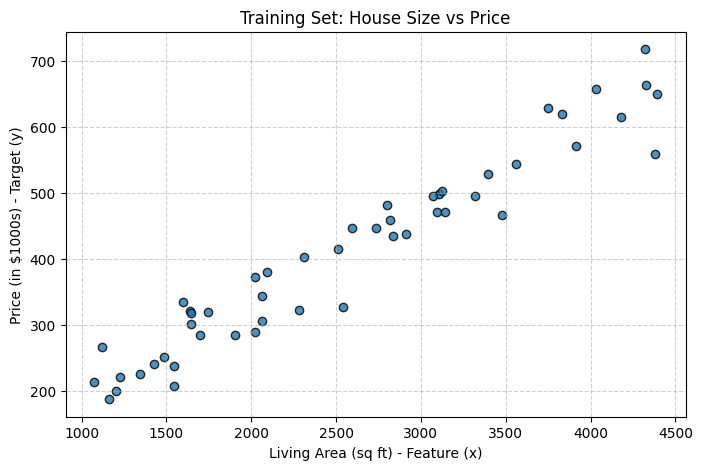

In [3]:
# House Size vs. Price dataset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def generate_housing_data(num_samples=100, seed=42):
    """
    Generates a synthetic dataset mapping house sizes (sq ft) to prices ($1000s).
    Follows a realistic linear trend with Gaussian noise.
    """
    np.random.seed(seed)
    
    # 1. Generate Independent Variable (x): Size in square feet
    # Most typical houses range from 1000 to 4500 sq ft
    sizes = np.random.uniform(low=1000, high=4500, size=num_samples)
    
    # 2. Define the true underlying relationship (Hypothesis: y = theta_0 + theta_1 * x)
    # Let's assume a base price of $50k (intercept) and $140 per square foot (slope)
    true_intercept = 50.0  # in thousands ($50,000)
    true_slope = 0.14      # $140 per sq ft translates to 0.14k per sq ft
    
    # 3. Generate Dependent Variable (y) with injected Gaussian Noise
    # Noise standard deviation represents market variance (e.g., condition, micro-location)
    noise = np.random.normal(loc=0.0, scale=40.0, size=num_samples) # +/- $40k variance
    
    prices = true_intercept + (true_slope * sizes) + noise
    
    # 4. Clean up metrics to realistic constraints (e.g., prices shouldn't be negative)
    prices = np.clip(prices, a_min=10.0, a_max=None)
    
    # 5. Build the DataFrame
    df = pd.DataFrame({
        'Size_SqFt': np.round(sizes, 1),
        'Price_1000s': np.round(prices, 2)
    })
    
    return df

# --- Execution ---
if __name__ == "__main__":
    # Generate 50 training examples
    dataset = generate_housing_data(num_samples=50)
    
    # Preview the dataset
    print("--- First 5 Training Examples (x^(i), y^(i)) ---")
    print(dataset.head())
    
    # Optional: Save to CSV for your pipeline
    # dataset.to_csv('housing_prices.csv', index=False)
    
    # Plotting the dataset to visualize the distribution
    plt.figure(figsize=(8, 5))
    plt.scatter(dataset['Size_SqFt'], dataset['Price_1000s'], color='#1f77b4', edgecolors='k', alpha=0.8)
    plt.title('Training Set: House Size vs Price')
    plt.xlabel('Living Area (sq ft) - Feature (x)')
    plt.ylabel('Price (in $1000s) - Target (y)')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

## The Cost Function
- The definitive goal of the learning algorithm is to choose a parameter vector $\theta$ such that the predictions $h_\theta(x)$ are as close to the true labels $y$ as possible across the entire empirical training set.
        $$h_\theta(x) \approx y$$

- **The Loss Metric** To quantify performance, we evaluate the residual difference $(h_\theta(x) - y)$. To penalize larger deviations more heavily and ensure mathematical smoothness for optimization, we square this error.Summing over all $m$ training examples gives the Ordinary Least Squares (OLS) Cost Function, denoted as $J(\theta)$:$$J(\theta) = \frac{1}{2} \sum_{i=1}^{m} \left( h_\theta(x^{(i)}) - y^{(i)} \right)^2$$